# SafetyVision — PPE Compliance System (Final Build)

**Student:** Hnin Aung  
**Course:** ITAI 1378 - Computer Vision and AI  
**Project Tier:** Tier 2

This notebook is my working proof of concept. It fine-tunes a YOLO11 object detector on a real
PPE dataset, measures its accuracy on data it never trained on, runs it on sample images, and then
uses a compliance component to turn the detections into a simple "compliant / violation" report.

**How to run:** open in Google Colab, set the runtime to a **T4 GPU** (Runtime -> Change runtime type -> T4 GPU), then Run all.


## 1. Setup
Install the libraries and confirm we have a GPU (training is much faster on GPU).

In [10]:
!pip install -q ultralytics roboflow
import ultralytics, torch
ultralytics.checks()
print("GPU available:", torch.cuda.is_available())

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)
GPU available: True


## 2. Get the dataset
I use a public PPE dataset from Roboflow Universe (classes: Gloves, Hard_hat, Mask, Person, Safety_boots, Vest).

**One-time step:** make a free account at roboflow.com, open Settings -> API Keys, and copy your
private API key. Paste it below. (Free and takes a minute.)

In [11]:
from roboflow import Roboflow

# Paste your free Roboflow API key between the quotes:
ROBOFLOW_API_KEY = "U5sPU2AmoJ3oE6jSP1VG"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("sdp-lfigk").project("ppe-detection-ozhfb")
dataset = project.version(14).download("yolov11")

print("Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /content/PPE-DETECTION-14


## 3. Train the detector
I start from the small pretrained `yolo11n` model and fine-tune it on the PPE data (transfer learning).
25 epochs is enough for a proof of concept; I can raise it later for better accuracy.

In [3]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")   # start from pretrained weights (transfer learning)

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    name="safetyvision_ppe"
)
print("Training finished. Best weights saved in the run folder above.")

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PPE-DETECTION-14/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=safetyvision_ppe, nbs=64, 

## 4. Measure accuracy on unseen data
This is the honest test: I evaluate on the **test split**, which the model never trained on.
The key number is mAP@0.5 (mean Average Precision) — my Blueprint target was at least 0.80.

In [4]:
# Load the best weights from training and evaluate on the test split
best_model = YOLO("runs/detect/safetyvision_ppe/weights/best.pt")

metrics = best_model.val(split="test")
print("mAP@0.5      :", round(float(metrics.box.map50), 3))
print("mAP@0.5:0.95 :", round(float(metrics.box.map), 3))
print("Precision    :", round(float(metrics.box.mp), 3))
print("Recall       :", round(float(metrics.box.mr), 3))

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1126.1±527.1 MB/s, size: 46.5 KB)
val: Scanning /content/PPE-DETECTION-14/test/labels... 213 images, 30 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 213/213 2.4Kit/s 0.1s
val: New cache created: /content/PPE-DETECTION-14/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 4.0it/s 3.5s
                   all        213        789       0.83      0.869      0.867      0.585
                Gloves         94        158      0.875      0.838      0.885      0.513
              Hard_hat         79         88      0.837      0.874      0.909      0.677
                  Mask         59         69      0.623      0.855       0.66      0.424
                Person        126        157       0.94      0.8

## 5. Run the detector on sample images
Here I run the trained model on a few test images and show the boxes it draws.

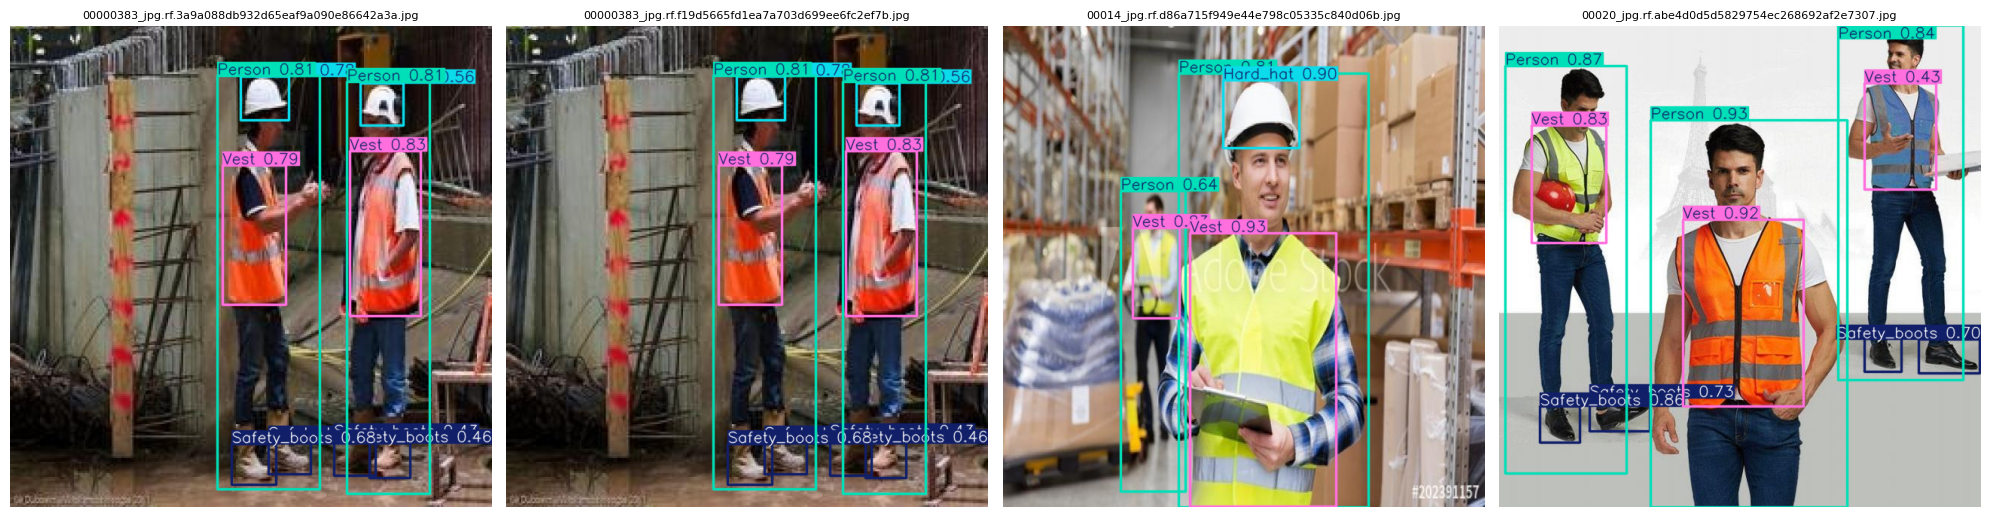

In [5]:
import glob, os
import matplotlib.pyplot as plt
from PIL import Image

test_images = sorted(glob.glob(f"{dataset.location}/test/images/*.jpg"))[:4]

fig, axes = plt.subplots(1, len(test_images), figsize=(20, 6))
for ax, img_path in zip(axes, test_images):
    r = best_model.predict(img_path, conf=0.25, verbose=False)[0]
    ax.imshow(r.plot()[..., ::-1])   # BGR -> RGB
    ax.axis("off")
    ax.set_title(os.path.basename(img_path), fontsize=8)
plt.tight_layout(); plt.show()

## 6. The compliance component (the "Tier 2" second part)
The detector only finds objects. This component turns those detections into a decision: for each image
it checks whether the **required** PPE is present, and flags a violation if something is missing.

For this proof of concept I treat **hard hat** and **safety vest** as the required items.
Associating each item with a specific person is a planned next step (see the last slide).

Image   : 00000383_jpg.rf.3a9a088db932d65eaf9a090e86642a3a.jpg
Detected: ['Hard_hat', 'Person', 'Safety_boots', 'Vest']
Required: ['Hard_hat', 'Vest']
Missing : none
RESULT  : COMPLIANT
---------------------------------------------


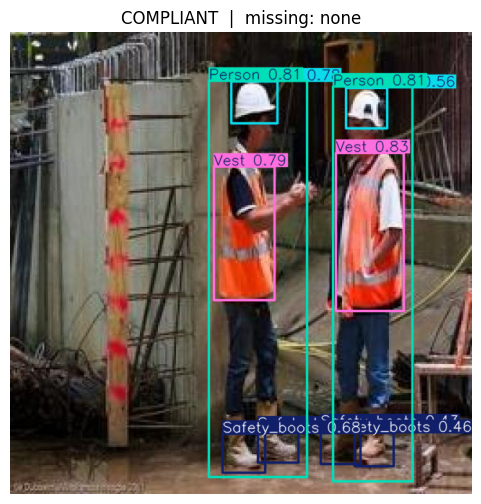

Image   : 00000383_jpg.rf.f19d5665fd1ea7a703d699ee6fc2ef7b.jpg
Detected: ['Hard_hat', 'Person', 'Safety_boots', 'Vest']
Required: ['Hard_hat', 'Vest']
Missing : none
RESULT  : COMPLIANT
---------------------------------------------


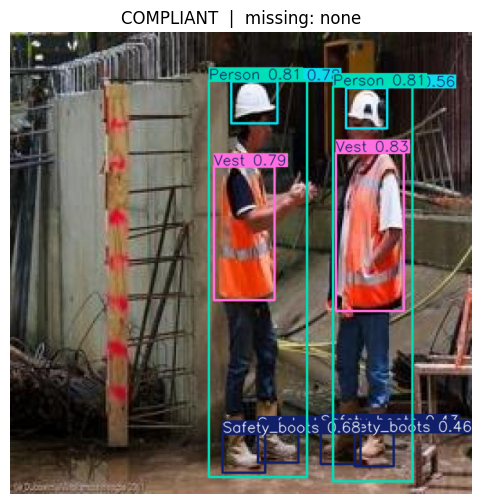

Image   : 00014_jpg.rf.d86a715f949e44e798c05335c840d06b.jpg
Detected: ['Hard_hat', 'Person', 'Vest']
Required: ['Hard_hat', 'Vest']
Missing : none
RESULT  : COMPLIANT
---------------------------------------------


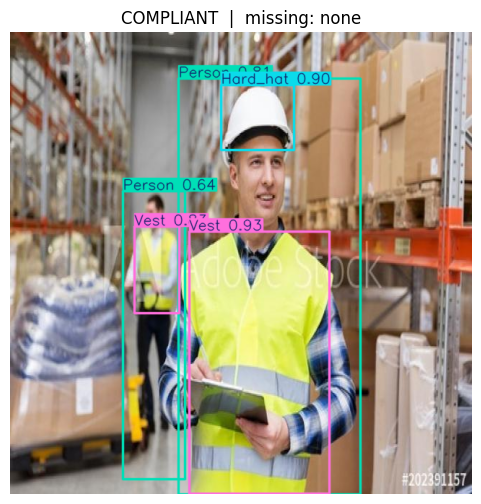

Image   : 00020_jpg.rf.abe4d0d5d5829754ec268692af2e7307.jpg
Detected: ['Person', 'Safety_boots', 'Vest']
Required: ['Hard_hat', 'Vest']
Missing : ['Hard_hat']
RESULT  : VIOLATION
---------------------------------------------


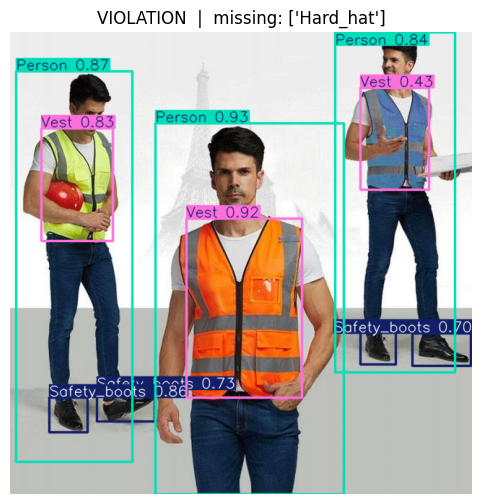

In [6]:
REQUIRED_PPE = ["Hard_hat", "Vest"]

def check_compliance(image_path, conf=0.25, show=True):
    """Run the detector on one image and report compliance."""
    r = best_model.predict(image_path, conf=conf, verbose=False)[0]
    names = r.names
    detected = sorted(set(names[int(c)] for c in r.boxes.cls))
    missing = [item for item in REQUIRED_PPE if item not in detected]
    status = "COMPLIANT" if not missing else "VIOLATION"

    print(f"Image   : {os.path.basename(image_path)}")
    print(f"Detected: {detected}")
    print(f"Required: {REQUIRED_PPE}")
    print(f"Missing : {missing if missing else 'none'}")
    print(f"RESULT  : {status}")
    print("-" * 45)

    if show:
        plt.figure(figsize=(7, 6))
        plt.imshow(r.plot()[..., ::-1]); plt.axis("off")
        plt.title(f"{status}  |  missing: {missing if missing else 'none'}")
        plt.show()
    return status, missing

# Run the compliance check on a few test images
for img in test_images:
    check_compliance(img)

## 7. A failure case (honest analysis)
A good proof of concept shows where it struggles, not just where it works. Below I look for an image
where the model misses an item or makes a wrong call, and I explain why in the next markdown cell.

Image   : 00022_jpg.rf.7c409da8bf41566994339d9d573f203a.jpg
Detected: ['Vest']
Required: ['Hard_hat', 'Vest']
Missing : ['Hard_hat']
RESULT  : VIOLATION
---------------------------------------------
Image   : 00027_jpg.rf.ab7f1f47757504f421059002323221d8.jpg
Detected: ['Person', 'Vest']
Required: ['Hard_hat', 'Vest']
Missing : ['Hard_hat']
RESULT  : VIOLATION
---------------------------------------------
Image   : 00037_jpg.rf.f24ceb8730fac868176e8a8d8aa4f606.jpg
Detected: ['Hard_hat', 'Person', 'Vest']
Required: ['Hard_hat', 'Vest']
Missing : none
RESULT  : COMPLIANT
---------------------------------------------
Image   : 00041_jpg.rf.4ca66fcf3eaddeb44599792854a854b1.jpg
Detected: ['Gloves', 'Person', 'Safety_boots', 'Vest']
Required: ['Hard_hat', 'Vest']
Missing : ['Hard_hat']
RESULT  : VIOLATION
---------------------------------------------
Image   : 00049_jpg.rf.b6dfe73e770d16d8721763b2e71c7255.jpg
Detected: ['Vest']
Required: ['Hard_hat', 'Vest']
Missing : ['Hard_hat']
RESULT  : V

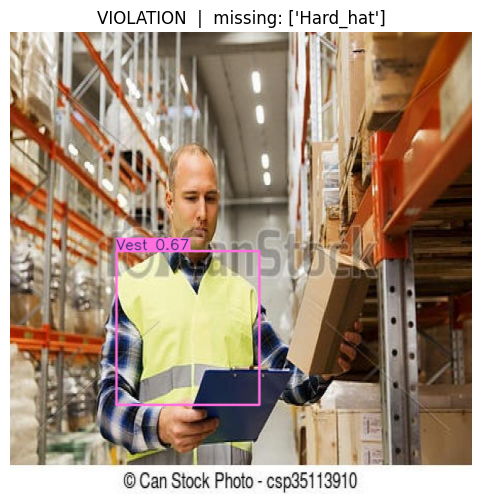

In [7]:
# Scan more test images and print any where the model flags a violation,
# so I can inspect whether it is right or wrong (a possible failure case).
more_images = sorted(glob.glob(f"{dataset.location}/test/images/*.jpg"))[4:14]

for img in more_images:
    status, missing = check_compliance(img, show=False)

# Then display one interesting case in detail (change the index after looking at the printout):
if more_images:
    check_compliance(more_images[0])

**My failure-case analysis:** *(fill this in after you run it)*
Describe one image where the system got it wrong — for example, it missed a hard hat that was small,
turned away, or a similar color to the background, or it flagged a violation when the item was actually
there but partly hidden. Explain *why* this likely happened (small object, occlusion, lighting, or few
training examples of that case). Honest failure analysis earns credit.

## 8. Experiment: how the confidence threshold changes the decisions
Following the "change one thing and compare" idea, I run the compliance check at two different
confidence thresholds and count how many images get flagged as violations. A lower threshold catches
more but risks false alarms; a higher threshold is stricter but can miss real gaps.

In [8]:
all_test = sorted(glob.glob(f"{dataset.location}/test/images/*.jpg"))[:30]

for thr in [0.25, 0.50]:
    violations = 0
    for img in all_test:
        r = best_model.predict(img, conf=thr, verbose=False)[0]
        detected = set(r.names[int(c)] for c in r.boxes.cls)
        if any(item not in detected for item in REQUIRED_PPE):
            violations += 1
    print(f"Confidence {thr:.2f}  ->  {violations} of {len(all_test)} images flagged as violations")

print("\nTrade-off: a lower threshold flags more images (safer, but more false alarms);")
print("a higher threshold flags fewer (stricter, but may miss real missing-PPE cases).")

Confidence 0.25  ->  23 of 30 images flagged as violations
Confidence 0.50  ->  25 of 30 images flagged as violations

Trade-off: a lower threshold flags more images (safer, but more false alarms);
a higher threshold flags fewer (stricter, but may miss real missing-PPE cases).


## 9. Save results for my GitHub repo
This saves annotated example images and the metrics so I can put them in the `results/` folder.

In [9]:
import shutil, json

os.makedirs("results", exist_ok=True)

# Save a few annotated predictions
for i, img in enumerate(test_images):
    r = best_model.predict(img, conf=0.25, verbose=False)[0]
    Image.fromarray(r.plot()[..., ::-1]).save(f"results/prediction_{i+1}.jpg")

# Save the metrics
summary = {
    "mAP@0.5": round(float(metrics.box.map50), 3),
    "mAP@0.5:0.95": round(float(metrics.box.map), 3),
    "precision": round(float(metrics.box.mp), 3),
    "recall": round(float(metrics.box.mr), 3),
    "required_ppe": REQUIRED_PPE,
    "epochs": 25,
    "model": "yolo11n fine-tuned",
}
with open("results/metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

# Copy the training curves image if it exists
curve = "runs/detect/safetyvision_ppe/results.png"
if os.path.exists(curve):
    shutil.copy(curve, "results/training_curves.png")

print("Saved to results/ :", os.listdir("results"))
print("\nTip: download the results/ folder and the best.pt weights, and add them to your GitHub repo.")

Saved to results/ : ['prediction_4.jpg', 'prediction_1.jpg', 'metrics.json', 'prediction_3.jpg', 'training_curves.png', 'prediction_2.jpg']

Tip: download the results/ folder and the best.pt weights, and add them to your GitHub repo.


## Conclusion
SafetyVision takes a real image, detects PPE with a fine-tuned YOLO11 model, and the compliance
component turns those detections into a clear compliant-or-violation report. It runs end to end on
images it has never seen, which is exactly what a proof of concept needs to show. The honest next
steps are associating each PPE item with a specific person and running the system on live video.